Epoch 0, Loss: 0.28318958906443975
Epoch 500, Loss: 0.24925259794647245
Epoch 1000, Loss: 0.2452260077391049
Epoch 1500, Loss: 0.2346596429458533
Epoch 2000, Loss: 0.21241230382004306
Epoch 2500, Loss: 0.1831671052051993
Epoch 3000, Loss: 0.15033145189893052
Epoch 3500, Loss: 0.10070506151082814
Epoch 4000, Loss: 0.057155633872042824
Epoch 4500, Loss: 0.03306687988732494
Epoch 5000, Loss: 0.0209294284760546
Epoch 5500, Loss: 0.014461235631481197
Epoch 6000, Loss: 0.010684834548759514
Epoch 6500, Loss: 0.008293730731118592
Epoch 7000, Loss: 0.006678721837546685
Epoch 7500, Loss: 0.005531260405031542
Epoch 8000, Loss: 0.004682699451579699
Epoch 8500, Loss: 0.004034686946105643
Epoch 9000, Loss: 0.0035266748846633244
Epoch 9500, Loss: 0.0031196628836273506

Predictions:
[[0.03730284]
 [0.9491398 ]
 [0.94480964]
 [0.06425255]]


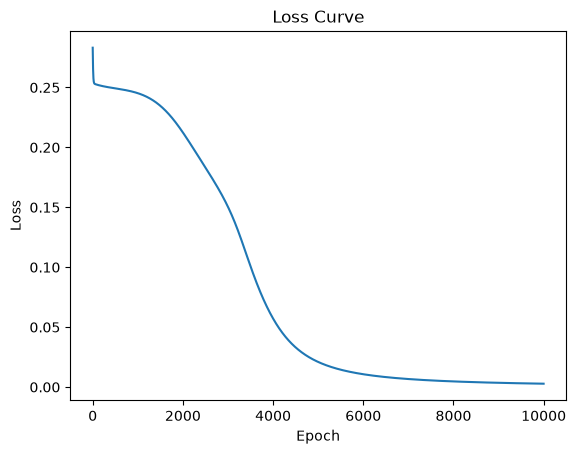

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# XOR dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

# Sigmoid
def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    return x*(1-x)

np.random.seed(42)

# Initialize weights
W1 = np.random.randn(2,4)
b1 = np.zeros((1,4))

W2 = np.random.randn(4,1)
b2 = np.zeros((1,1))

learning_rate = 0.1
epochs = 10000

losses = []

for epoch in range(epochs):

    # Forward pass
    hidden_input = np.dot(X,W1)+b1
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output,W2)+b2
    prediction = sigmoid(final_input)

    # Loss
    loss = np.mean((y-prediction)**2)
    losses.append(loss)

    # Backpropagation
    output_error = y-prediction
    d_output = output_error*sigmoid_derivative(prediction)

    hidden_error = np.dot(d_output,W2.T)
    d_hidden = hidden_error*sigmoid_derivative(hidden_output)

    # Update weights
    W2 += np.dot(hidden_output.T,d_output)*learning_rate
    b2 += np.sum(d_output,axis=0,keepdims=True)*learning_rate

    W1 += np.dot(X.T,d_hidden)*learning_rate
    b1 += np.sum(d_hidden,axis=0,keepdims=True)*learning_rate

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

print("\nPredictions:")
print(prediction)

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()